In [ ]:
from google.colab import drive
import pandas as pd
from scipy import stats

# Mount Google Drive
drive.mount('/content/drive')

# Update folder path if files are inside a subfolder
swe = pd.read_csv('/content/drive/MyDrive/county_swe_averages_1980_2025.csv')
temp = pd.read_csv('/content/drive/MyDrive/case_studies_temp.csv')

# Merge on year
df = swe.merge(temp, on='year')

# Run Pearson correlation for each county
counties = ['san_juan', 'gunnison', 'summit']

results = []
for c in counties:
    r, p = stats.pearsonr(df[f'{c}_temp'], df[f'{c}_swe'])
    results.append({
        'County': c.replace('_', ' ').title(),
        'Pearson_r': round(r, 4),
        'P_Value': round(p, 4),
        'N': len(df)
    })

results_df = pd.DataFrame(results)
print(results_df.to_string(index=False))

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
  County  Pearson_r  P_Value  N
San Juan    -0.5657   0.0000 46
Gunnison    -0.4128   0.0044 46
  Summit    -0.3173   0.0317 46


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


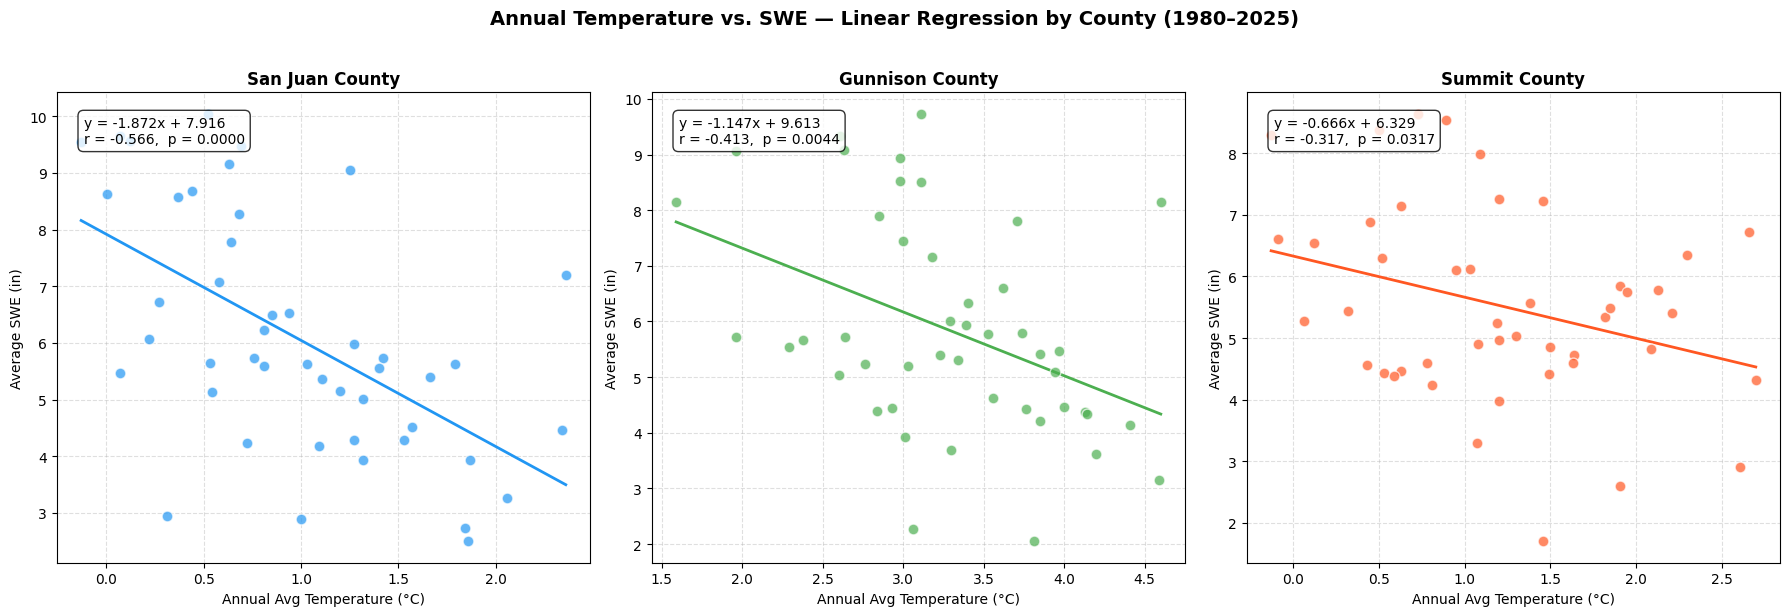

Plot saved to Google Drive!


In [ ]:
from google.colab import drive
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt

# Mount Google Drive
drive.mount('/content/drive')

# Load files
swe  = pd.read_csv('/content/drive/MyDrive/county_swe_averages_1980_2025.csv')
temp = pd.read_csv('/content/drive/MyDrive/case_studies_temp.csv')

# Merge on year
df = swe.merge(temp, on='year')

counties = ['san_juan', 'gunnison', 'summit']
titles   = ['San Juan County', 'Gunnison County', 'Summit County']
colors   = ['#2196F3', '#4CAF50', '#FF5722']

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Annual Temperature vs. SWE — Linear Regression by County (1980–2025)',
             fontsize=14, fontweight='bold', y=1.02)

for ax, county, title, color in zip(axes, counties, titles, colors):
    x = df[f'{county}_temp']
    y = df[f'{county}_swe']

    # Linear regression
    slope, intercept, r, p, se = stats.linregress(x, y)

    # Regression line
    x_line = np.linspace(x.min(), x.max(), 200)
    y_line = slope * x_line + intercept

    # Plot
    ax.scatter(x, y, color=color, alpha=0.7, edgecolors='white', s=60, zorder=3)
    ax.plot(x_line, y_line, color=color, linewidth=2, label='Regression line')

    # Equation label
    sign = '+' if intercept >= 0 else '-'
    eq   = f'y = {slope:.3f}x {sign} {abs(intercept):.3f}'
    stats_text = f'{eq}\nr = {r:.3f},  p = {p:.4f}'
    ax.text(0.05, 0.95, stats_text, transform=ax.transAxes,
            fontsize=10, verticalalignment='top',
            bbox=dict(boxstyle='round,pad=0.4', facecolor='white', alpha=0.8))

    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_xlabel('Annual Avg Temperature (°C)', fontsize=10)
    ax.set_ylabel('Average SWE (in)', fontsize=10)
    ax.grid(True, linestyle='--', alpha=0.4)

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/county_swe_temp_regression.png', dpi=150, bbox_inches='tight')
plt.show()
print("Plot saved to Google Drive!")